In [2]:
import numpy as np

x_min = 0
x_max = 6

sigma = 0.7

jump_rate = 1.0
jump_std = 0.7

dt = 1.0

rng = np.random.default_rng(0)
print('rng sample:', rng.standard_normal(3))

rng sample: [ 0.12573022 -0.13210486  0.64042265]


Computing exit probability...
Computing survivor density for x0=1.5
Computing survivor density for x0=3.0
Running rollout...
step 1: survival=0.8712
step 2: survival=0.7788
step 3: survival=0.7049
step 4: survival=0.6401
step 5: survival=0.5825
step 6: survival=0.5300
step 7: survival=0.4835
step 8: survival=0.4417


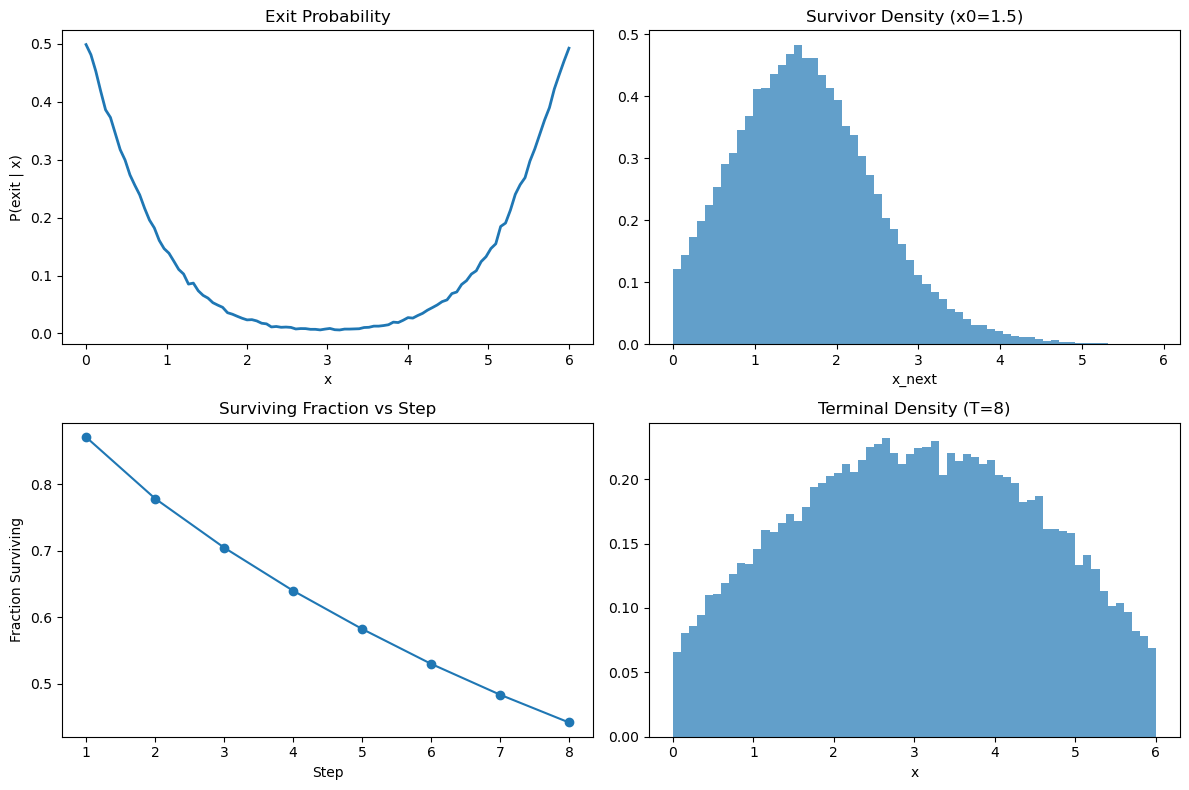


Done.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================

x_min = 0.0
x_max = 6.0

sigma = 0.7

jump_rate = 1.0
jump_mean = 0.0
jump_std = 0.7

dt = 1.0

rng = np.random.default_rng(0)

# ============================================================
# ONE LARGE STEP OF THE JUMP-DIFFUSION
# ============================================================

def one_step(x):
    """
    Simulate one coarse step:

        dX = sigma dW + dJ

    with absorbing boundaries [0,6].
    """

    x = np.asarray(x)

    # -----------------------------
    # Brownian motion
    # -----------------------------

    brownian = (
        sigma
        * np.sqrt(dt)
        * rng.standard_normal(len(x))
    )

    # -----------------------------
    # Poisson jump counts
    # -----------------------------

    n_jumps = rng.poisson(
        jump_rate * dt,
        size=len(x)
    )

    # -----------------------------
    # Total jump contribution
    # -----------------------------

    jump_total = np.zeros(len(x))

    for i in range(len(x)):

        n = n_jumps[i]

        if n > 0:

            jump_total[i] = rng.normal(
                loc=n * jump_mean,
                scale=np.sqrt(n) * jump_std
            )

    # -----------------------------
    # New position
    # -----------------------------

    x_new = x + brownian + jump_total

    # -----------------------------
    # Absorbing boundaries
    # -----------------------------

    alive = (
        (x_new >= x_min)
        &
        (x_new <= x_max)
    )

    return x_new, alive


# ============================================================
# B1 LEFT PANEL
# EXIT PROBABILITY
# ============================================================

def build_exit_probability():

    grid = np.linspace(0, 6, 100)

    exit_prob = []

    print("Computing exit probability...")

    for x0 in grid:

        x = np.full(10000, x0)

        x_new, alive = one_step(x)

        p_exit = np.mean(~alive)

        exit_prob.append(p_exit)

    return grid, np.array(exit_prob)


# ============================================================
# B1 MIDDLE/RIGHT
# SURVIVOR DENSITY
# ============================================================

def survivor_density(x0):

    print(f"Computing survivor density for x0={x0}")

    x = np.full(100000, x0)

    x_new, alive = one_step(x)

    survivors = x_new[alive]

    return survivors


# ============================================================
# B2 LEFT PANEL
# SURVIVING FRACTION
# ============================================================

def rollout_survival():

    N = 100000

    x = rng.uniform(
        x_min,
        x_max,
        size=N
    )

    alive = np.ones(
        N,
        dtype=bool
    )

    survival_fraction = []

    print("Running rollout...")

    for step in range(8):

        idx = np.where(alive)[0]

        x_new, alive_local = one_step(x[idx])

        alive[idx[~alive_local]] = False

        x[idx[alive_local]] = x_new[alive_local]

        survival_fraction.append(
            alive.mean()
        )

        print(
            f"step {step+1}: "
            f"survival={alive.mean():.4f}"
        )

    terminal_survivors = x[alive]

    return (
        np.array(survival_fraction),
        terminal_survivors
    )


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # B1 EXIT PROBABILITY
    # --------------------------------------------------------

    grid, exit_prob = build_exit_probability()

    # --------------------------------------------------------
    # B1 SURVIVOR DENSITIES
    # --------------------------------------------------------

    survivors_15 = survivor_density(1.5)

    survivors_30 = survivor_density(3.0)

    # --------------------------------------------------------
    # B2 ROLLOUT
    # --------------------------------------------------------

    survival_curve, terminal_density = rollout_survival()

    # ========================================================
    # CREATE FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8)
    )

    # ========================================================
    # PANEL 1
    # ========================================================

    axes[0,0].plot(
        grid,
        exit_prob,
        linewidth=2
    )

    axes[0,0].set_title(
        "Exit Probability"
    )

    axes[0,0].set_xlabel("x")

    axes[0,0].set_ylabel(
        "P(exit | x)"
    )

    # ========================================================
    # PANEL 2
    # ========================================================

    axes[0,1].hist(
        survivors_15,
        bins=60,
        density=True,
        alpha=0.7
    )

    axes[0,1].set_title(
        "Survivor Density (x0=1.5)"
    )

    axes[0,1].set_xlabel(
        "x_next"
    )

    # ========================================================
    # PANEL 3
    # ========================================================

    axes[1,0].plot(
        np.arange(1,9),
        survival_curve,
        marker='o'
    )

    axes[1,0].set_title(
        "Surviving Fraction vs Step"
    )

    axes[1,0].set_xlabel(
        "Step"
    )

    axes[1,0].set_ylabel(
        "Fraction Surviving"
    )

    # ========================================================
    # PANEL 4
    # ========================================================

    axes[1,1].hist(
        terminal_density,
        bins=60,
        density=True,
        alpha=0.7
    )

    axes[1,1].set_title(
        "Terminal Density (T=8)"
    )

    axes[1,1].set_xlabel(
        "x"
    )

    plt.tight_layout()

    plt.savefig(
        "b1_b2_from_scratch.png",
        dpi=150
    )

    plt.show()

    print("\nDone.")